# 02a: Explore canonical telemetry

Read-only, DuckDB-backed exploration. 

Queries are filtered and capped before data reaches pandas.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

HERE = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'src' / 'ausgrid_analysis').is_dir()), None)
assert PROJECT_ROOT is not None, 'Start Jupyter inside the ausgrid_analysis project.'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from ausgrid_analysis.config import load_config
from ausgrid_analysis.db import canonical_output_path, duplicate_audit_path
from ausgrid_analysis.metadata import metadata_output_path
from ausgrid_analysis.schemas import sql_string

pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')

## Select a bounded slice

Edit these values freely. `SERIAL=None` chooses a site from the selected month. `MAX_ROWS` is a hard guardrail.

In [2]:
CONFIG_PATH = PROJECT_ROOT / 'analysis.toml'
MONTH = '2024-09'
SERIAL = None
DATE_FROM = None  # local date, e.g. '2025-04-10'
DATE_TO = None    # local date, exclusive
PHASES = ['A', 'B', 'C']
MAX_ROWS = 100_000

config = load_config(CONFIG_PATH, check_inputs=False)
full_scope = config.scope(None, None)
canonical_dir = canonical_output_path(config, full_scope)
assert canonical_dir.is_dir(), f'Run notebook 01 first: {canonical_dir}'
canonical_glob = str(canonical_dir / '**' / '*.parquet')
con = duckdb.connect()
con.execute(f"SET memory_limit='{config.processing.memory_limit}'")
con.execute(f"SET threads={min(config.processing.threads, 4)}")
con.execute("SET TimeZone='UTC'")
con.execute(f"CREATE VIEW canonical AS SELECT * FROM read_parquet({sql_string(canonical_glob)}, hive_partitioning=true)")
print('Canonical source:', canonical_dir)

Canonical source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\canonical_phase


In [3]:
year, month = map(int, MONTH.split('-'))
overview = con.execute('''
    SELECT count(*) n_rows, count(DISTINCT serial) n_sites,
           min(timestamp_local) first_local, max(timestamp_local) last_local,
           count_if(NOT voltage_physical_ok) invalid_voltage_rows,
           count_if(p_export_w IS NULL) null_p_rows,
           count_if(q_absorbing_var IS NULL) null_q_rows,
           count_if(NOT metadata_available) rows_without_metadata
    FROM canonical WHERE year_utc=? AND month_utc=?
''', [year, month]).fetchdf()
display(overview)

site_choices = con.execute('''
    SELECT serial, analysis_cohort, install_phase_count, count(*) n_rows,
           count_if(p_export_w IS NOT NULL) n_power_rows
    FROM canonical WHERE year_utc=? AND month_utc=?
    GROUP BY ALL ORDER BY n_power_rows DESC LIMIT 50
''', [year, month]).fetchdf()
display(site_choices.head(20))
if SERIAL is None:
    SERIAL = str(site_choices.iloc[0]['serial'])
print('Selected serial:', SERIAL)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_rows,n_sites,first_local,last_local,invalid_voltage_rows,null_p_rows,null_q_rows,rows_without_metadata
0,23219460,1327,2024-09-01 10:00:00,2024-10-01 09:55:00,140526.0,5236953.0,5236953.0,1146705.0


,serial,analysis_cohort,install_phase_count,n_rows,n_power_rows
0,810824465,solar_only,1,25920,25920.0
1,810871734,NaN,<NA>,25920,25920.0
2,811118743,solar_only,1,25920,25920.0
3,810715264,solar_battery,3,25920,25920.0
4,810972095,solar_battery,1,25920,25920.0
5,811118785,solar_battery,3,25920,25920.0
6,810869801,solar_only,1,25920,25920.0
7,810824314,solar_battery,3,25920,25920.0
8,810206649,solar_battery,3,25920,25920.0
9,810871061,solar_only,3,25920,25920.0


Selected serial: 810824465


In [5]:
# Change SERIAL if wanted:
SERIAL = 810140828
SERIAL = 810492661

where = ['year_utc=?', 'month_utc=?', 'cast(serial as varchar)=?']
params = [year, month, str(SERIAL)]
if DATE_FROM:
    where.append('timestamp_local >= cast(? as timestamp)'); params.append(DATE_FROM)
if DATE_TO:
    where.append('timestamp_local < cast(? as timestamp)'); params.append(DATE_TO)
where.append("phase IN (SELECT unnest(?))"); params.append(PHASES)
query = f'''SELECT * FROM canonical WHERE {' AND '.join(where)} ORDER BY timestamp_utc, phase LIMIT ?'''
sample = con.execute(query, [*params, MAX_ROWS]).fetchdf()
assert len(sample) < MAX_ROWS, 'Row cap reached: narrow dates/phases before interpreting plots.'
display(sample.head())
display(sample.groupby('phase')[['voltage_v','p_export_w','q_absorbing_var','current_a']].agg(['count','median','min','max']))

,serial,timestamp_utc,timestamp_local,phase,voltage_v,current_a,active_power_raw_w,reactive_power_raw_var,p_export_w,q_absorbing_var,q_generator_var,source_month,source_file,duplicate_count,duplicate_source_file_count,duplicate_status,row_has_null_measurement,voltage_physical_ok,metadata_available,analysis_cohort,install_phase_count,month_utc,site_bucket,year_utc
0,810492661,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,A,244.081024,5.509911,-1317.141110,265.470276,1317.141110,265.470276,-265.470276,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024
1,810492661,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,B,244.606659,5.007292,-1215.037110,81.683170,1215.037110,81.683170,-81.683170,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024
2,810492661,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,C,244.142868,2.097394,-342.048248,306.311900,342.048248,306.311900,-306.311900,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024
3,810492661,2024-09-01 00:05:00+00:00,2024-09-01 10:05:00,A,243.637833,5.657296,-1357.982670,234.839111,1357.982670,234.839111,-234.839111,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024
4,810492661,2024-09-01 00:05:00+00:00,2024-09-01 10:05:00,B,243.926422,5.324736,-1291.615110,66.367570,1291.615110,66.367570,-66.367570,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024


voltage_v                                     p_export_w              \
          count      median         min         max      count      median   
phase                                                                        
A          8640  243.936737  238.536072  249.059113       8640 -102.103958   
B          8640  244.441757  239.989300  248.275818       8640  -45.946780   
C          8640  243.174042  235.495621  248.770523       8640  -30.631187   

                              q_absorbing_var                          \
              min         max           count      median         min   
phase                                                                   
A     -7637.37600  3190.74878            8640   -7.657797 -199.102722   
B     -3384.74600  3149.90723            8640 -153.155945 -316.522278   
C     -4630.41455  2389.23267            8640  -91.893560 -275.680700   

                  current_a                                 
              max     count    median       min        max  
phase                                                       
A       959.77720      8640  1.277332  0.294769  31.835043  
B      1010.82916      8640  1.311344  0.219187  13.933499  
C       832.14730      8640  1.035470  0.355234  19.896902

In [6]:
sample

,serial,timestamp_utc,timestamp_local,phase,voltage_v,current_a,active_power_raw_w,reactive_power_raw_var,p_export_w,q_absorbing_var,q_generator_var,source_month,source_file,duplicate_count,duplicate_source_file_count,duplicate_status,row_has_null_measurement,voltage_physical_ok,metadata_available,analysis_cohort,install_phase_count,month_utc,site_bucket,year_utc
0,810492661,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,A,244.081024,5.509911,-1317.141110,265.470276,1317.141110,265.470276,-265.470276,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024
1,810492661,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,B,244.606659,5.007292,-1215.037110,81.683170,1215.037110,81.683170,-81.683170,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024
2,810492661,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,C,244.142868,2.097394,-342.048248,306.311900,342.048248,306.311900,-306.311900,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024
3,810492661,2024-09-01 00:05:00+00:00,2024-09-01 10:05:00,A,243.637833,5.657296,-1357.982670,234.839111,1357.982670,234.839111,-234.839111,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024
4,810492661,2024-09-01 00:05:00+00:00,2024-09-01 10:05:00,B,243.926422,5.324736,-1291.615110,66.367570,1291.615110,66.367570,-66.367570,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25915,810492661,2024-09-30 23:50:00+00:00,2024-10-01 09:50:00,B,243.163742,8.332891,-2021.658330,91.893560,2021.658330,91.893560,-91.893560,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024
25916,810492661,2024-09-30 23:50:00+00:00,2024-10-01 09:50:00,C,243.885200,3.658158,-811.726440,306.311900,811.726440,306.311900,-306.311900,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024
25917,810492661,2024-09-30 23:55:00+00:00,2024-10-01 09:55:00,A,244.338684,8.348007,-2031.868770,158.261139,2031.868770,158.261139,-158.261139,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024
25918,810492661,2024-09-30 23:55:00+00:00,2024-10-01 09:55:00,B,243.163742,8.427367,-2047.184330,137.840347,2047.184330,137.840347,-137.840347,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024


## Time series and voltage relationships

These are net-meter P/Q against revenue-meter voltage. They are exploratory.

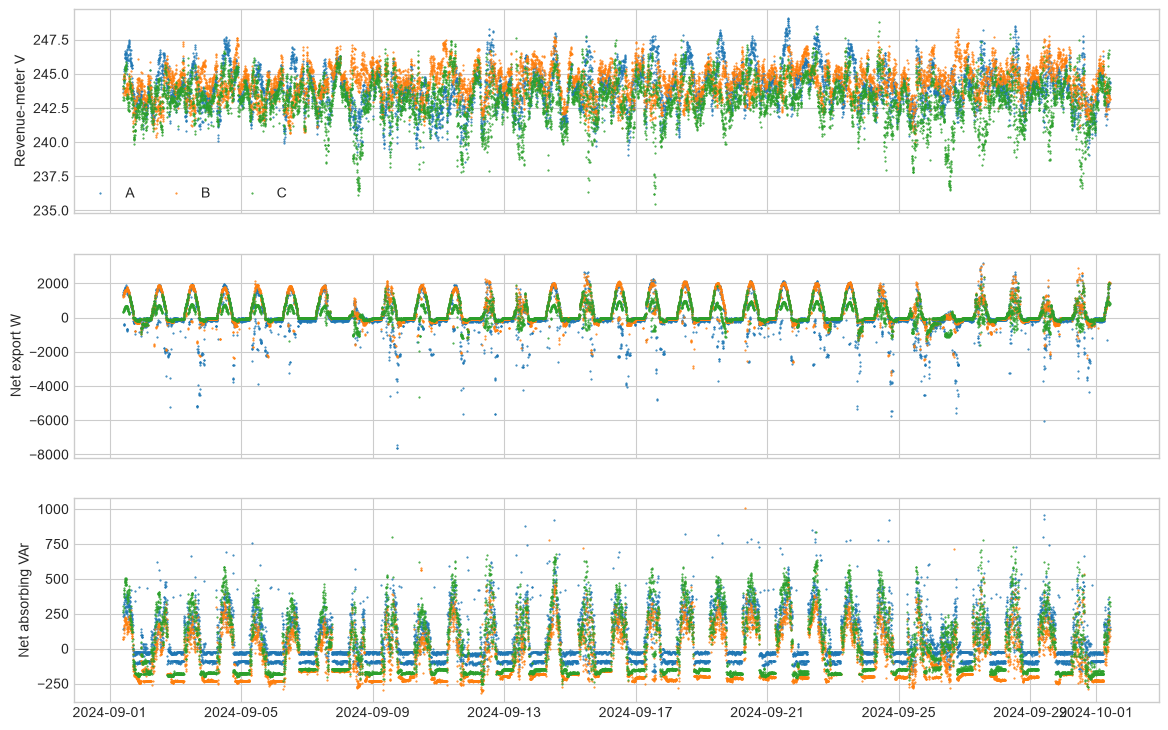

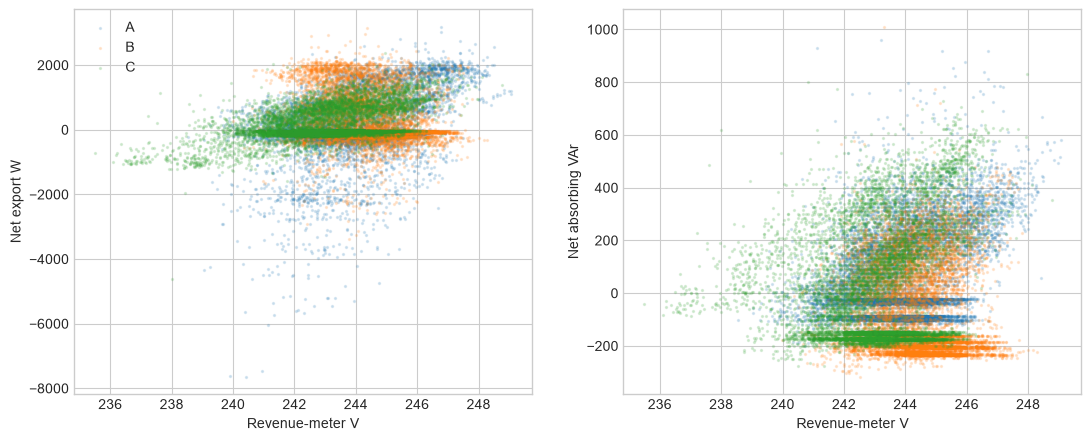

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for phase, g in sample.groupby('phase'):
    axes[0].plot(g.timestamp_local, g.voltage_v.where(g.voltage_physical_ok), '.', ms=1, label=phase)
    axes[1].plot(g.timestamp_local, g.p_export_w, '.', ms=1, label=phase)
    axes[2].plot(g.timestamp_local, g.q_absorbing_var, '.', ms=1, label=phase)
axes[0].set_ylabel('Revenue-meter V'); axes[1].set_ylabel('Net export W'); axes[2].set_ylabel('Net absorbing VAr')
axes[0].legend(ncol=3); plt.show()

valid = sample[sample.voltage_physical_ok & sample.p_export_w.notna() & sample.q_absorbing_var.notna()]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for phase, g in valid.groupby('phase'):
    axes[0].scatter(g.voltage_v, g.p_export_w, s=2, alpha=.15, label=phase)
    axes[1].scatter(g.voltage_v, g.q_absorbing_var, s=2, alpha=.15, label=phase)
axes[0].set(xlabel='Revenue-meter V', ylabel='Net export W'); axes[1].set(xlabel='Revenue-meter V', ylabel='Net absorbing VAr')
axes[0].legend(); plt.show()

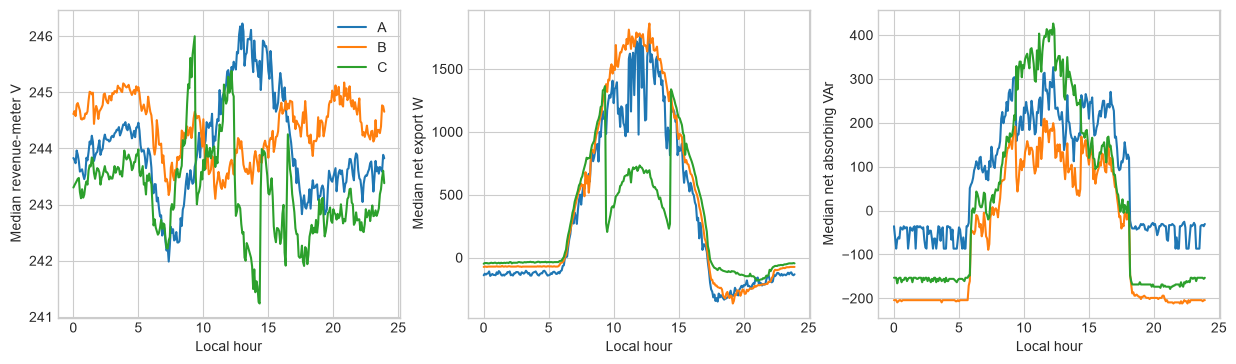

,rows,p_null,q_null,current_null,voltage_zero
phase,,,,,
A,8640,0,0,0,0
B,8640,0,0,0,0
C,8640,0,0,0,0


In [8]:
daily = (sample.assign(local_hour=sample.timestamp_local.dt.hour + sample.timestamp_local.dt.minute/60)
         .groupby(['phase','local_hour'])[['voltage_v','p_export_w','q_absorbing_var']].median().reset_index())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for phase, g in daily.groupby('phase'):
    for ax, col in zip(axes, ['voltage_v','p_export_w','q_absorbing_var']): ax.plot(g.local_hour, g[col], label=phase)
axes[0].set_ylabel('Median revenue-meter V'); axes[1].set_ylabel('Median net export W'); axes[2].set_ylabel('Median net absorbing VAr')
for ax in axes: ax.set_xlabel('Local hour')
axes[0].legend(); plt.show()

quality = sample.groupby('phase').agg(
    rows=('serial','size'), p_null=('p_export_w',lambda x:x.isna().sum()),
    q_null=('q_absorbing_var',lambda x:x.isna().sum()),
    current_null=('current_a',lambda x:x.isna().sum()),
    voltage_zero=('voltage_v',lambda x:(x<=0).sum()))
display(quality)

## Sign, metadata, duplicate provenance and timezone checks

In [9]:
sample['local_period'] = pd.cut(sample.timestamp_local.dt.hour, [-1,5,9,15,19,24], labels=['night','morning','midday','evening','late'])
display(sample.groupby(['local_period','phase'], observed=True)[['active_power_raw_w','p_export_w','reactive_power_raw_var','q_absorbing_var']].median())
print('Working signs only — active export sign:', config.assumptions.active_export_sign,
      '; reactive absorbing sign:', config.assumptions.reactive_absorbing_sign)

metadata = con.execute(f'''SELECT * FROM read_parquet({sql_string(metadata_output_path(config))}) WHERE cast(serial as varchar)=?''', [str(SERIAL)]).fetchdf()
display(metadata)
audit = duplicate_audit_path(config, full_scope)
if audit.is_file():
    display(con.execute(f'''SELECT * FROM read_parquet({sql_string(audit)}) WHERE cast(serial as varchar)=? ORDER BY row_count DESC LIMIT 25''', [str(SERIAL)]).fetchdf())

display(con.execute('''SELECT timestamp_utc, timestamp_local,
    date_diff('minute', cast(timestamp_utc AS TIMESTAMP), timestamp_local) utc_offset_minutes
    FROM canonical WHERE cast(serial as varchar)=? ORDER BY timestamp_utc LIMIT 20''', [str(SERIAL)]).fetchdf())
print('Close connection when finished: con.close()')

active_power_raw_w   p_export_w  reactive_power_raw_var  \
local_period phase                                                            
night        A              127.629944  -127.629944              -40.841583   
             B               71.472770   -71.472770             -204.207916   
             C               35.736385   -35.736385             -153.155945   
morning      A             -428.836600   428.836600              160.813736   
             B             -505.414581   505.414581               35.736385   
             C             -479.888600   479.888600               91.893560   
midday       A            -1036.355220  1036.355220              219.523514   
             B            -1286.509890  1286.509890              122.524750   
             C             -622.834167   622.834167              275.680700   
evening      A              224.628708  -224.628708               25.525990   
             B              209.313110  -209.313110             -117.419556   
             C               61.262375   -61.262375              -79.130570   
late         A              163.366333  -163.366333              -35.736385   
             B              193.997528  -193.997528             -204.207916   
             C              102.103958  -102.103958             -168.471527   

                    q_absorbing_var  
local_period phase                   
night        A           -40.841583  
             B          -204.207916  
             C          -153.155945  
morning      A           160.813736  
             B            35.736385  
             C            91.893560  
midday       A           219.523514  
             B           122.524750  
             C           275.680700  
evening      A            25.525990  
             B          -117.419556  
             C           -79.130570  
late         A           -35.736385  
             B          -204.207916  
             C          -168.471527

Working signs only — active export sign: -1 ; reactive absorbing sign: 1


,serial,controlled_load,der_type,install_phase_count,approved_capacity_kw,solar_capacity_kw,solar_manufacturer,solar_model,battery_kwh,battery_manufacturer,battery_model,battery_inverter_capacity_kw,solar_install_year,battery_install_year,zone_external_id,sub_external_id,sub_lat,sub_long,fy26_evm_test,has_battery,analysis_cohort,s_rated_kva,s_rated_source
0,810492661,No,Solar,3,30,9.35,Ginlong Technologies Co Ltd,S5-GR3P10K-AU (AS4777-2 2020),0.0,0,0,0.0,2023,NaN,1173,8906,-32.976424,151.602331,0,False,solar_only,NaN,unavailable


,serial,measure_time,phase,row_count,payload_variant_count,source_file_count,duplicate_class
0,810492661,2025-01-09 06:10:00,C,256,1,1,identical_duplicate
1,810492661,2025-01-09 06:10:00,B,256,1,1,identical_duplicate
2,810492661,2025-01-09 06:10:00,A,256,1,1,identical_duplicate
3,810492661,2025-03-11 03:05:00,C,16,1,1,identical_duplicate
4,810492661,2025-03-11 03:40:00,B,16,1,1,identical_duplicate
5,810492661,2025-03-11 04:30:00,C,16,1,1,identical_duplicate
6,810492661,2025-03-11 06:50:00,C,16,1,1,identical_duplicate
7,810492661,2025-03-11 05:30:00,C,16,1,1,identical_duplicate
8,810492661,2025-03-11 02:35:00,B,16,1,1,identical_duplicate
9,810492661,2025-03-11 03:20:00,A,16,1,1,identical_duplicate


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,timestamp_utc,timestamp_local,utc_offset_minutes
0,2024-08-01 00:00:00+00:00,2024-08-01 10:00:00,600
1,2024-08-01 00:00:00+00:00,2024-08-01 10:00:00,600
2,2024-08-01 00:00:00+00:00,2024-08-01 10:00:00,600
3,2024-08-01 00:05:00+00:00,2024-08-01 10:05:00,600
4,2024-08-01 00:05:00+00:00,2024-08-01 10:05:00,600
5,2024-08-01 00:05:00+00:00,2024-08-01 10:05:00,600
6,2024-08-01 00:10:00+00:00,2024-08-01 10:10:00,600
7,2024-08-01 00:10:00+00:00,2024-08-01 10:10:00,600
8,2024-08-01 00:10:00+00:00,2024-08-01 10:10:00,600
9,2024-08-01 00:15:00+00:00,2024-08-01 10:15:00,600


Close connection when finished: con.close()


# Scratch book

In [10]:
sample

,serial,timestamp_utc,timestamp_local,phase,voltage_v,current_a,active_power_raw_w,reactive_power_raw_var,p_export_w,q_absorbing_var,q_generator_var,source_month,source_file,duplicate_count,duplicate_source_file_count,duplicate_status,row_has_null_measurement,voltage_physical_ok,metadata_available,analysis_cohort,install_phase_count,month_utc,site_bucket,year_utc,local_period
0,810492661,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,A,244.081024,5.509911,-1317.141110,265.470276,1317.141110,265.470276,-265.470276,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024,midday
1,810492661,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,B,244.606659,5.007292,-1215.037110,81.683170,1215.037110,81.683170,-81.683170,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024,midday
2,810492661,2024-09-01 00:00:00+00:00,2024-09-01 10:00:00,C,244.142868,2.097394,-342.048248,306.311900,342.048248,306.311900,-306.311900,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024,midday
3,810492661,2024-09-01 00:05:00+00:00,2024-09-01 10:05:00,A,243.637833,5.657296,-1357.982670,234.839111,1357.982670,234.839111,-234.839111,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024,midday
4,810492661,2024-09-01 00:05:00+00:00,2024-09-01 10:05:00,B,243.926422,5.324736,-1291.615110,66.367570,1291.615110,66.367570,-66.367570,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024,midday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25915,810492661,2024-09-30 23:50:00+00:00,2024-10-01 09:50:00,B,243.163742,8.332891,-2021.658330,91.893560,2021.658330,91.893560,-91.893560,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024,morning
25916,810492661,2024-09-30 23:50:00+00:00,2024-10-01 09:50:00,C,243.885200,3.658158,-811.726440,306.311900,811.726440,306.311900,-306.311900,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024,morning
25917,810492661,2024-09-30 23:55:00+00:00,2024-10-01 09:55:00,A,244.338684,8.348007,-2031.868770,158.261139,2031.868770,158.261139,-158.261139,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024,morning
25918,810492661,2024-09-30 23:55:00+00:00,2024-10-01 09:55:00,B,243.163742,8.427367,-2047.184330,137.840347,2047.184330,137.840347,-137.840347,2024-09,jm_unswnmissep24,1,1,unique,False,True,True,solar_only,3,9,1,2024,morning


In [11]:
CONFIG_PATH = PROJECT_ROOT / 'analysis.toml'
MONTH = '2024-09'
SERIAL = None
DATE_FROM = None  # local date, e.g. '2025-04-10'
DATE_TO = None    # local date, exclusive
PHASES = ['A', 'B', 'C']
MAX_ROWS = 100_000

config = load_config(CONFIG_PATH, check_inputs=False)
full_scope = config.scope(None, None)
canonical_dir = canonical_output_path(config, full_scope)
assert canonical_dir.is_dir(), f'Run notebook 01 first: {canonical_dir}'
canonical_glob = str(canonical_dir / '**' / '*.parquet')
con = duckdb.connect()
con.execute(f"SET memory_limit='{config.processing.memory_limit}'")
con.execute(f"SET threads={min(config.processing.threads, 4)}")
con.execute("SET TimeZone='UTC'")
con.execute(f"CREATE VIEW canonical AS SELECT * FROM read_parquet({sql_string(canonical_glob)}, hive_partitioning=true)")
print('Canonical source:', canonical_dir)

Canonical source: C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\derived\canonical_phase


In [12]:
voltage_high_sites = con.execute("""
    SELECT CAST(serial AS VARCHAR) AS serial,
           COUNT(*) AS n_rows,
           MIN(timestamp_local) AS first_seen,
           MAX(timestamp_local) AS last_seen
    FROM canonical
    WHERE year_utc = ? AND month_utc = ?
      AND voltage_v > 253
    GROUP BY serial
    ORDER BY n_rows DESC
""", [year, month]).fetchdf()

display(voltage_high_sites)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,serial,n_rows,first_seen,last_seen
0,810973387,3044,2024-09-01 10:25:00,2024-09-20 09:50:00
1,810787015,2771,2024-09-01 10:00:00,2024-09-20 09:35:00
2,810961976,2558,2024-09-01 11:00:00,2024-09-20 09:30:00
3,810578490,2484,2024-09-01 10:30:00,2024-10-01 09:55:00
4,810508901,2103,2024-09-01 11:30:00,2024-09-30 15:20:00
...,...,...,...,...
221,810950958,1,2024-09-15 12:20:00,2024-09-15 12:20:00
222,810886469,1,2024-09-11 13:05:00,2024-09-11 13:05:00
223,810870577,1,2024-09-14 11:55:00,2024-09-14 11:55:00
224,811051670,1,2024-09-28 13:25:00,2024-09-28 13:25:00


In [13]:
year, month = map(int, MONTH.split('-'))
overview = con.execute('''
    SELECT count(*) n_rows, count(DISTINCT serial) n_sites,
           min(timestamp_local) first_local, max(timestamp_local) last_local,
           count_if(NOT voltage_physical_ok) invalid_voltage_rows,
           count_if(p_export_w IS NULL) null_p_rows,
           count_if(q_absorbing_var IS NULL) null_q_rows,
           count_if(NOT metadata_available) rows_without_metadata
    FROM canonical WHERE year_utc=? AND month_utc=?
''', [year, month]).fetchdf()
display(overview)

site_choices = con.execute('''
    SELECT serial, analysis_cohort, install_phase_count, count(*) n_rows,
           count_if(p_export_w IS NOT NULL) n_power_rows
    FROM canonical WHERE year_utc=? AND month_utc=?
    GROUP BY ALL ORDER BY n_power_rows DESC LIMIT 50
''', [year, month]).fetchdf()
display(site_choices.head(20))
if SERIAL is None:
    SERIAL = str(site_choices.iloc[0]['serial'])
print('Selected serial:', SERIAL)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_rows,n_sites,first_local,last_local,invalid_voltage_rows,null_p_rows,null_q_rows,rows_without_metadata
0,23219460,1327,2024-09-01 10:00:00,2024-10-01 09:55:00,140526.0,5236953.0,5236953.0,1146705.0


,serial,analysis_cohort,install_phase_count,n_rows,n_power_rows
0,810633925,solar_only,3,25920,25920.0
1,810961875,solar_only,1,25920,25920.0
2,810660771,solar_only,3,25920,25920.0
3,810232063,solar_battery,3,25920,25920.0
4,810715288,solar_only,3,25920,25920.0
5,810685394,solar_only,3,25920,25920.0
6,810874433,solar_only,3,25920,25920.0
7,811168856,NaN,<NA>,25920,25920.0
8,810780682,solar_battery,3,25920,25920.0
9,811106190,solar_only,3,25920,25920.0


Selected serial: 810633925
